# SNP direct summary (nested 5x3)

Consolidacion reproducible de resultados SNP direct (sin recalcular modelos), con el mismo esquema que PCA20/PCA50.

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# Global font scaling (+2) for publication readability
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 14,
})


In [2]:
root = Path.cwd().resolve()
if not (root / 'results').exists():
    candidates = [
        root / 'repo',
        root / 'nested5x3_unificados',
        root.parent,
        root.parent / 'repo',
        root.parent / 'nested5x3_unificados',
    ]
    for cand in candidates:
        if (cand / 'results').exists():
            root = cand
            break

# Carpeta principal (mismo estilo que PCA)
out_dir = root / 'results' / 'snp_summary_nested5x3'
out_dir.mkdir(parents=True, exist_ok=True)

# Carpeta de compatibilidad solicitada para el xlsx
compat_dir = root / 'results' / 'snp_summary'
compat_dir.mkdir(parents=True, exist_ok=True)

# Fuente principal de resultados SNP direct ya calculados
snp_source = root / 'results' / 'snp_blocks_notebook_nested5x3' / 'all_results.csv'
if not snp_source.exists():
    raise FileNotFoundError(f'No existe fuente SNP: {snp_source}')

# Fuente opcional GBLUP para comparativa
gblup_source = root / 'results' / 'snp_blocks_notebook_nested5x3_gblup' / 'all_results.csv'

In [3]:
# 1) Preparar dataframe base (sin recalcular)
raw = pd.read_csv(snp_source)

required_cols = ['model', 'trait', 'pearson_r', 'r2', 'rmse']
missing = [c for c in required_cols if c not in raw.columns]
if missing:
    raise ValueError(f'Faltan columnas requeridas en fuente SNP: {missing}')

master = raw.copy()
master['representation'] = 'SNP_DIRECT'

# MAE no siempre viene en SNP direct clÃ¡sico: mantener columna consistente
if 'mae' not in master.columns:
    master['mae'] = pd.NA

master['model'] = master['model'].astype(str).str.strip().str.lower()
master['trait'] = master['trait'].astype(str).str.strip().str.lower()

master = master[['representation', 'model', 'trait', 'pearson_r', 'r2', 'rmse', 'mae']].copy()
master['source_file'] = snp_source.as_posix()
master['notes'] = ''

# Validaciones pedidas
n_nulls = int(master[['model', 'trait', 'pearson_r', 'r2', 'rmse']].isna().sum().sum())
key_cols = ['representation', 'model', 'trait']
n_dups = int(master.duplicated(key_cols).sum())

print(f'Filas master: {len(master)}')
print(f'Nulos en columnas clave: {n_nulls}')
print(f'Duplicados ({key_cols}): {n_dups}')

if n_nulls > 0:
    display(master[master[['model', 'trait', 'pearson_r', 'r2', 'rmse']].isna().any(axis=1)].head())
if n_dups > 0:
    display(master[master.duplicated(key_cols, keep=False)].sort_values(key_cols))

master = master.drop_duplicates(key_cols).reset_index(drop=True)

# Orden de traits por bloques
trait_disease = ['blumeria_graminis', 'puccinia_hordei', 'ramularia_collo_cygni', 'rhynchosporium']
trait_agronomic = ['heading_date', 'lodging', 'plant_height']
extra_traits = [t for t in sorted(master['trait'].unique()) if t not in set(trait_disease + trait_agronomic)]
trait_order = trait_disease + trait_agronomic + extra_traits

master['trait'] = pd.Categorical(master['trait'], categories=trait_order, ordered=True)
master = master.sort_values(['model', 'trait']).reset_index(drop=True)

display(master.head())

Filas master: 21
Nulos en columnas clave: 0
Duplicados (['representation', 'model', 'trait']): 0


,representation,model,trait,pearson_r,r2,rmse,mae,source_file,notes
0,SNP_DIRECT,elasticnet,blumeria_graminis,0.735424,0.540195,0.789258,<NA>,C:/Users/Reyes/OneDrive/PC_REYES/Master_Big_Da...,
1,SNP_DIRECT,elasticnet,puccinia_hordei,0.704021,0.493778,0.845710,<NA>,C:/Users/Reyes/OneDrive/PC_REYES/Master_Big_Da...,
2,SNP_DIRECT,elasticnet,ramularia_collo_cygni,0.277836,0.011854,1.114339,<NA>,C:/Users/Reyes/OneDrive/PC_REYES/Master_Big_Da...,
3,SNP_DIRECT,elasticnet,rhynchosporium,0.171385,-0.109114,0.963914,<NA>,C:/Users/Reyes/OneDrive/PC_REYES/Master_Big_Da...,
4,SNP_DIRECT,elasticnet,heading_date,0.800564,0.640615,19.049703,<NA>,C:/Users/Reyes/OneDrive/PC_REYES/Master_Big_Da...,


In [4]:
# 2) Tabla resumen por modelo
summary_base = (
    master.groupby('model', as_index=False)
    .agg(
        mean_r=('pearson_r', 'mean'),
        mean_r2=('r2', 'mean')
    )
)

best_idx = master.groupby('model')['pearson_r'].idxmax()
worst_idx = master.groupby('model')['pearson_r'].idxmin()

best_df = master.loc[best_idx, ['model', 'trait', 'pearson_r']].rename(columns={'trait': 'best_trait', 'pearson_r': 'best_r'})
worst_df = master.loc[worst_idx, ['model', 'trait', 'pearson_r']].rename(columns={'trait': 'worst_trait', 'pearson_r': 'worst_r'})

snp_model_summary = (
    summary_base
    .merge(best_df, on='model', how='left')
    .merge(worst_df, on='model', how='left')
    .sort_values('mean_r', ascending=False)
    .reset_index(drop=True)
)

num_cols = ['mean_r', 'mean_r2', 'best_r', 'worst_r']
snp_model_summary[num_cols] = snp_model_summary[num_cols].round(3)

display(
    snp_model_summary.style.format({
        'mean_r': '{:.3f}',
        'mean_r2': '{:.3f}',
        'best_r': '{:.3f}',
        'worst_r': '{:.3f}',
    })
)

,model,mean_r,mean_r2,best_trait,best_r,worst_trait,worst_r
0,xgboost,0.656,0.476,lodging,0.874,rhynchosporium,0.286
1,ridge,0.650,0.466,lodging,0.877,rhynchosporium,0.252
2,elasticnet,0.624,0.427,lodging,0.871,rhynchosporium,0.171


In [5]:
# 3) Export tablas (master + resumen)
master_out_csv = out_dir / 'snp_nested5x3_master_results.csv'
model_summary_csv = out_dir / 'snp_nested5x3_model_summary.csv'
model_summary_xlsx = out_dir / 'snp_nested5x3_model_summary.xlsx'

master.to_csv(master_out_csv, index=False)
snp_model_summary.to_csv(model_summary_csv, index=False)
snp_model_summary.to_excel(model_summary_xlsx, index=False)

# Export adicional solicitado explÃ­citamente
compat_xlsx = compat_dir / 'snp_model_summary.xlsx'
compat_csv = compat_dir / 'snp_model_summary.csv'
snp_model_summary.to_excel(compat_xlsx, index=False)
snp_model_summary.to_csv(compat_csv, index=False)

print('Guardado:')
print(master_out_csv)
print(model_summary_csv)
print(model_summary_xlsx)
print(compat_xlsx)
print(compat_csv)

Guardado:
C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\repo\results\snp_summary_nested5x3\snp_nested5x3_master_results.csv
C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\repo\results\snp_summary_nested5x3\snp_nested5x3_model_summary.csv
C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\repo\results\snp_summary_nested5x3\snp_nested5x3_model_summary.xlsx
C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\repo\results\snp_summary\snp_model_summary.xlsx
C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\repo\results\snp_summary\snp_model_summary.csv


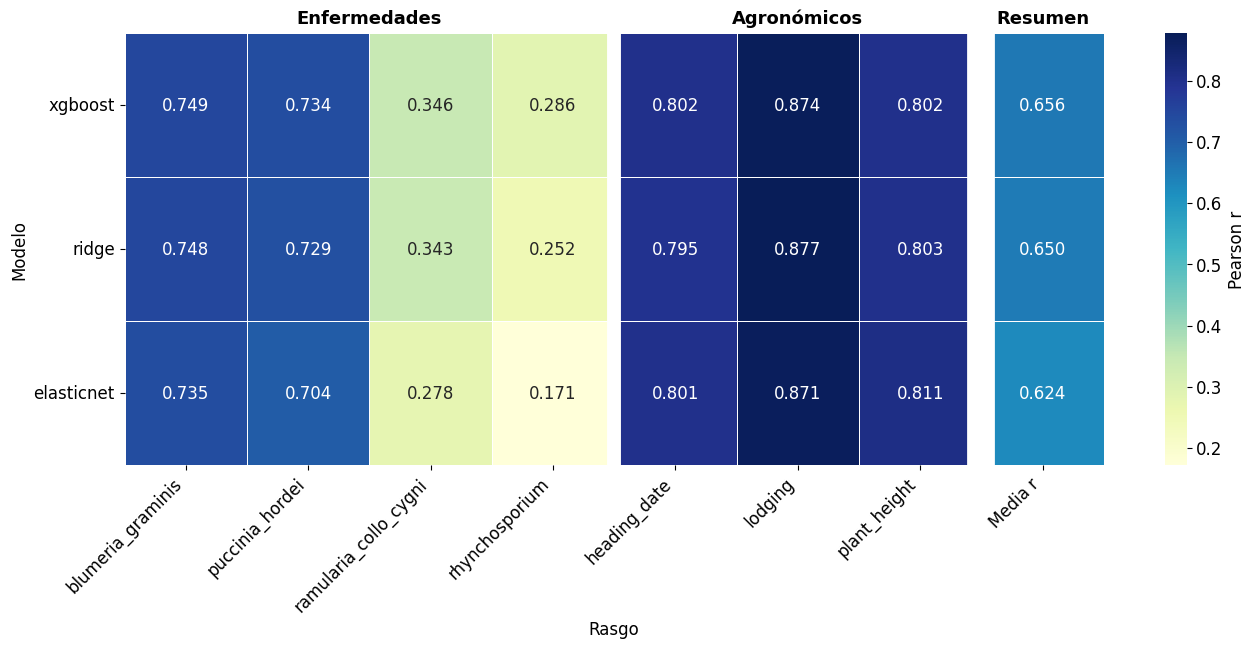

In [10]:
# =========================================================
# Heatmap SNP direct con separación visual limpia por líneas
# =========================================================

pivot = master.pivot(index='model', columns='trait', values='pearson_r').reindex(columns=trait_order)
pivot['mean_r'] = pivot.mean(axis=1)
pivot = pivot.sort_values('mean_r', ascending=False)

# Orden final SIN columnas extra
heat_cols = trait_disease + trait_agronomic + ['mean_r']
plot_data = pivot[heat_cols]

plt.figure(figsize=(15.3, 7.2))
ax = sns.heatmap(
    plot_data,
    annot=True,
    fmt='.3f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson r'}
)

# Límites eje Y
ymin, ymax = ax.get_ylim()

# Separación enfermedades | agronómicos (suave)
ax.vlines(len(trait_disease), ymin, ymax, colors="#FFFFFF", linewidth=10)

# Separación antes de la media (más marcada)
ax.vlines(len(trait_disease) + len(trait_agronomic), ymin, ymax, colors="#FFFFFF", linewidth=20)

# Etiquetas superiores
y_top = -0.10   # antes -0.18 (ahora quedan un poco más abajo, más separadas del título)

ax.text(len(trait_disease) / 2, y_top, 'Enfermedades',
        ha='center', va='center', fontsize=13, fontweight='bold')
ax.text(len(trait_disease) + len(trait_agronomic) / 2, y_top, 'Agronómicos',
        ha='center', va='center', fontsize=13, fontweight='bold')
ax.text(len(heat_cols) - 0.5, y_top, 'Resumen',
        ha='center', va='center', fontsize=13, fontweight='bold')

# # Título
# ax.set_title(
#     'Rendimiento predictivo (Pearson r) por modelo y rasgo bajo representación SNP direct',
#     pad=36,      # antes 28
#     y=1.08       # empuja el título hacia arriba
# )

# Márgenes
plt.subplots_adjust(top=0.82, bottom=0.26, left=0.16, right=0.96)  # antes top=0.86

ax.set_xlabel('Rasgo')
ax.set_ylabel('Modelo')

# Etiquetas eje X
xticklabels = trait_disease + trait_agronomic + ['Media r']
ax.set_xticklabels(xticklabels, rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Ajuste de márgenes
plt.subplots_adjust(top=0.86, bottom=0.26, left=0.16, right=0.96)

plt.savefig(
    out_dir / 'snp_nested5x3_heatmap_pearson.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()


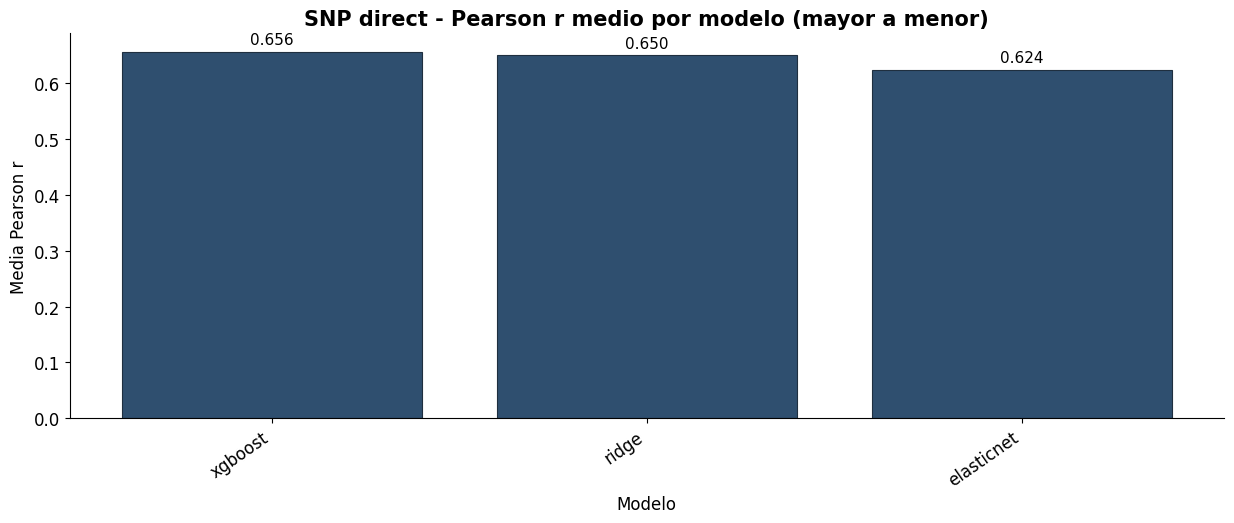

Guardado: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\repo\results\snp_summary_nested5x3\snp_nested5x3_barplot_mean_pearson.png


In [7]:
# 5) Barplot mean_r por modelo (ordenado)
plot_df = snp_model_summary.sort_values('mean_r', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12.5, 5.4))
bars = ax.bar(
    plot_df['model'],
    plot_df['mean_r'],
    color='#2F4F6F',
    edgecolor='#1F2F3F',
    linewidth=0.8
)

for bar, v in zip(bars, plot_df['mean_r']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008, f'{v:.3f}', ha='center', va='bottom', fontsize=11)

ax.set_title('SNP direct - Pearson r medio por modelo (mayor a menor)', fontsize=15, fontweight='bold')
ax.set_xlabel('Modelo')
ax.set_ylabel('Media Pearson r')
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df['model'], rotation=35, ha='right')

sns.despine(ax=ax)
plt.tight_layout()

barplot_out = out_dir / 'snp_nested5x3_barplot_mean_pearson.png'
plt.savefig(barplot_out, dpi=300, bbox_inches='tight')
plt.show()
print('Guardado:', barplot_out)

## Resumen de resultados SNP direct

In [8]:
# 6) Resumen final + comparativa opcional con GBLUP
summary_view = snp_model_summary.copy()
display(summary_view)

if gblup_source.exists():
    gblup_df = pd.read_csv(gblup_source)
    gblup_df['model'] = gblup_df['model'].astype(str).str.lower().str.strip()
    gblup_cmp = (
        gblup_df.groupby('model', as_index=False)
        .agg(mean_r=('pearson_r', 'mean'))
    )

    snp_cmp = summary_view[['model', 'mean_r']].copy()
    cmp_df = pd.concat([snp_cmp, gblup_cmp], ignore_index=True)
    cmp_df = cmp_df.sort_values('mean_r', ascending=False).reset_index(drop=True)
    cmp_df['mean_r'] = cmp_df['mean_r'].round(3)

    display(cmp_df)

    cmp_csv = out_dir / 'snp_vs_gblup_mean_r.csv'
    cmp_xlsx = out_dir / 'snp_vs_gblup_mean_r.xlsx'
    cmp_df.to_csv(cmp_csv, index=False)
    cmp_df.to_excel(cmp_xlsx, index=False)
    print('Guardado comparativa:', cmp_csv)
    print('Guardado comparativa:', cmp_xlsx)
else:
    print('Comparativa GBLUP omitida: no se encontrÃ³', gblup_source)

,model,mean_r,mean_r2,best_trait,best_r,worst_trait,worst_r
0,xgboost,0.656,0.476,lodging,0.874,rhynchosporium,0.286
1,ridge,0.650,0.466,lodging,0.877,rhynchosporium,0.252
2,elasticnet,0.624,0.427,lodging,0.871,rhynchosporium,0.171


,model,mean_r
0,gblup,0.666
1,xgboost,0.656
2,ridge,0.650
3,elasticnet,0.624


Guardado comparativa: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\repo\results\snp_summary_nested5x3\snp_vs_gblup_mean_r.csv
Guardado comparativa: C:\Users\Reyes\OneDrive\PC_REYES\Master_Big_Data_Data_Science\14MBID\2026\Code\repo\results\snp_summary_nested5x3\snp_vs_gblup_mean_r.xlsx
